In [1]:
import numpy as np
from numpy.polynomial.hermite import hermgauss
import math
from scipy.special import eval_hermite
from scipy.special import hermite
from matplotlib import pyplot as plt
from scipy.integrate import simpson

In [65]:
from functools import lru_cache

@lru_cache(maxsize=None)
def log_normalization_const_squared(nu, n):
    result = np.log(np.sqrt(2 * nu))
    result -= np.log(np.pow(np.pi, 1/2))
    result -= np.log(2) * (2*n)
    result -= math.lgamma(2 * n + 2)
    return result

def HO_energy(n_basis):
    diag = [2*n + 3/2 for n in range(0, n_basis)]
    energy = np.diag(diag)
    return energy

#def wavefunction(coefficients,x):
#    wavefunction=0
#    for k in range(len(coefficients)):
#        if x==0:
#            wavefunction+=np.exp(log_normalization_const_squared(0.5, k)/2) / np.sqrt(4*np.pi) * coefficients[k]*hermite(2*k+1).deriv()(0)*np.exp(-x*x/2)
#        else:
#            wavefunction+=np.exp(log_normalization_const_squared(0.5, k)/2) / np.sqrt(4*np.pi) * coefficients[k]*eval_hermite(2*k+1,x)/(x)*np.exp(-x*x/2)
#    return wavefunction

def wavefunction(coefficients, x):
    coefficients = np.asarray(coefficients)
    ks = np.arange(len(coefficients))
    log_norms = np.array([log_normalization_const_squared(0.5, k) for k in ks])
    norm_factors = np.exp(log_norms / 2) / np.sqrt(4 * np.pi)
    
    if x == 0:
        herm_vals = np.array([hermite(2*k+1).deriv()(0) for k in ks])
    else:
        herm_vals = np.array([eval_hermite(2*k+1, x) for k in ks]) / x
    
    return np.sum(norm_factors * coefficients * herm_vals) * np.exp(-x*x / 2)

def modified_hermite_polynomial(x, eta, d1, d2):
    return eval_hermite(d1, eta * x) * eval_hermite(d2, eta * x)

def potential_energy_entry(coefficients, n, m, nu, N, a, points, weights):
    # points e weights passati dall'esterno — calcolati una volta sola
    eta = np.sqrt(0.5)
    herm_vals = eval_hermite(2*m+1, eta * points) * eval_hermite(2*n+1, eta * points)
    
    psi_vals = np.array([wavefunction(coefficients, eta * p) for p in points])
    psi_no_exp = psi_vals / np.exp(-0.25 * points**2)
    
    integral = np.sum(weights / 2 * herm_vals * psi_no_exp**2)  # loop eliminato
    coefficient = (N-1)*a * np.sqrt(2)/2 * 4*np.pi * np.exp(
        (log_normalization_const_squared(nu, n) + log_normalization_const_squared(nu, m)) / 2
    )
    return coefficient * integral

def precompute_norm_factors(M):
    """Precalcola i fattori di normalizzazione per k=0..M-1"""
    log_norms = np.array([log_normalization_const_squared(0.5, k) for k in range(M)])
    return np.exp(log_norms / 2) / np.sqrt(4 * np.pi)  # shape: (M,)

def precompute_hermite_matrix(M, x_points):
    """
    Calcola H_{2k+1}(x) per tutti k e tutti i punti in una volta.
    shape: (M, len(x_points))
    """
    return np.array([eval_hermite(2*k+1, x_points) for k in range(M)])

def wavefunction_matrix(coefficients, x_points, hermite_matrix, norm_factors):
    """
    x_points: coordinate fisiche (già trasformate, es. eta * gauss_points)
    hermite_matrix: H_{2k+1}(x_points), shape (M, N_points)
    """
    # weighted[k, i] = norm_factors[k] * coefficients[k] * H_{2k+1}(x_points[i])
    weighted = (norm_factors * coefficients)[:, np.newaxis] * hermite_matrix
    psi_sum = np.sum(weighted, axis=0)  # shape: (N_points,)

    # Dividi per x (come nell'originale), gestendo x=0
    with np.errstate(divide='ignore', invalid='ignore'):
        psi = np.where(x_points != 0,
                       psi_sum / x_points * np.exp(-x_points**2 / 2),
                       0.0)  # o il limite corretto se necessario
    return psi

def potential_energy(coefficients, nu, N, a):
    M = len(coefficients)
    coefficients = np.asarray(coefficients)
    max_order = 6*M - 2
    points, weights = hermgauss(max_order)

    eta = np.sqrt(0.5)
    x_pts = eta * points

    norm_factors = precompute_norm_factors(M)
    hermite_matrix = precompute_hermite_matrix(M, x_pts)

    psi_vals = wavefunction_matrix(coefficients, x_pts, hermite_matrix, norm_factors)
    psi_no_exp = psi_vals / np.exp(-x_pts**2 / 2)  # ✅ coerente con x_pts

    log_norms_nu = np.array([log_normalization_const_squared(nu, k) for k in range(M)])

    result = np.zeros((M, M))
    for n in range(M):
        for m in range(n, M):
            herm_nm = eval_hermite(2*m+1, x_pts) * eval_hermite(2*n+1, x_pts)
            integral = np.sum(weights / 2 * herm_nm * psi_no_exp**2)
            coeff = (N-1)*a * np.sqrt(2)/2 * 4*np.pi * np.exp(
                (log_norms_nu[n] + log_norms_nu[m]) / 2
            )
            result[n, m] = coeff * integral
            result[m, n] = result[n, m]

    return result
def hamiltonian(coefficients, old_coefficients, alpha, nu, N, a):
    M=len(coefficients)
    HO=HO_energy(M)
    #print(HO)
    potential=(alpha)*potential_energy(coefficients, nu, N, a)+(1-alpha)*potential_energy(old_coefficients, nu, N, a)
    #print(potential)
    return HO+potential

wavefunction_vec = np.vectorize(wavefunction, excluded=[0])

def true_energy(coefficients, old_coefficients, N, a, mu):
    ho_energy = np.sum(coefficients**2 * (2*np.arange(len(coefficients)) + 1.5))

    x = np.arange(0.001, 10, 0.001)
    M = len(old_coefficients)
    norm_factors = precompute_norm_factors(M)
    herm_mat = precompute_hermite_matrix(M, x)
    psi = wavefunction_matrix(np.asarray(old_coefficients), x, herm_mat, norm_factors)

    wavefunction_integral = (N-1)*a * (4*np.pi)**2 * simpson(psi**4 * x**2, x)
    return ho_energy + wavefunction_integral/2, mu - ho_energy - wavefunction_integral

#true_energy([1,0,0,0],1000,1,0)
def ground_state(old_coefficients, old_old_coefficients, alpha, nu, N, a):
    energies, new_coefficients = np.linalg.eigh(hamiltonian(old_coefficients,old_old_coefficients, alpha, nu, N, a))
    return energies[0], new_coefficients[0]

#first_guess=[1,0,0,0,0,0,0,0,0,0]

#new_state=ground_state(first_guess,np.zeros(len(first_guess)),0.5,0.5,100,0.01)

def plot_state(coefficients, it):
    x = np.arange(0.001, 6, 0.01)
    M = len(coefficients)
    norm_factors = precompute_norm_factors(M)
    herm_mat = precompute_hermite_matrix(M, x)
    y = wavefunction_matrix(np.asarray(coefficients), x, herm_mat, norm_factors)
    plt.plot(x, y*y*x*x*4*np.pi, label=str(it))
    plt.legend(loc='upper right')
    #print("Area=",(simpson(y*y*x*x*4*np.pi,x)))
#plot_state(first_guess,1)
#plot_state(new_state[1],2)

E at  0  iteration=  1.5
Delta_E at  0  iteration=  0.0
E at  1  iteration=  1.5398543351507392
Delta_E at  1  iteration=  -0.07962896163383405
E at  2  iteration=  1.5413000780319466
Delta_E at  2  iteration=  -0.0028723113258577876
E at  3  iteration=  1.5442676313549468
Delta_E at  3  iteration=  -0.008801706634004869
E at  4  iteration=  1.5444830332032444
Delta_E at  4  iteration=  -0.00637059662867466
E at  5  iteration=  1.5447055911973588
Delta_E at  5  iteration=  -0.006815098375311121
E at  6  iteration=  1.544722990580576
Delta_E at  6  iteration=  -0.006644434644892172
E at  7  iteration=  1.5447403175271937
Delta_E at  7  iteration=  -0.006679025054969034
E at  8  iteration=  1.5447416952926554
Delta_E at  8  iteration=  -0.006665860918630903
E at  9  iteration=  1.5447430623139284
Delta_E at  9  iteration=  -0.006668588701374503
E at  10  iteration=  1.5447431715773068
Delta_E at  10  iteration=  -0.006667552190495363
Convergence reached because E doesn't decrease anymore

(np.float64(1.581141634984553),
 np.float64(1.5447431715773068),
 array([-9.99623302e-01,  2.61024368e-02, -7.81276893e-03,  2.98002491e-03,
        -1.25931896e-03,  5.65100852e-04, -2.64460922e-04,  1.27911845e-04,
        -6.36164589e-05, -3.24314393e-05,  1.69095484e-05, -9.00070093e-06,
        -4.88283597e-06,  2.69529601e-06,  1.51137427e-06,  8.59571556e-07,
        -4.95102424e-07, -2.88429521e-07,  1.69759226e-07,  1.00853702e-07,
         6.04406719e-08, -3.65216068e-08, -2.22450030e-08, -1.36555949e-08,
         8.44793007e-09,  5.26656632e-09,  3.30832729e-09, -2.09379197e-09,
        -1.33477416e-09, -8.56835695e-10,  5.53647577e-10,  3.59930425e-10,
         2.35310244e-10, -1.54627386e-10, -1.02083044e-10, -6.76807470e-11,
        -4.50482454e-11,  3.00946658e-11,  2.01763176e-11,  1.35744089e-11,
        -9.16544195e-12, -6.21156511e-12, -4.22622041e-12,  2.88743257e-12,
         1.98149055e-12,  1.36616327e-12, -9.46560464e-13, -6.59234011e-13,
         4.61696562e-13

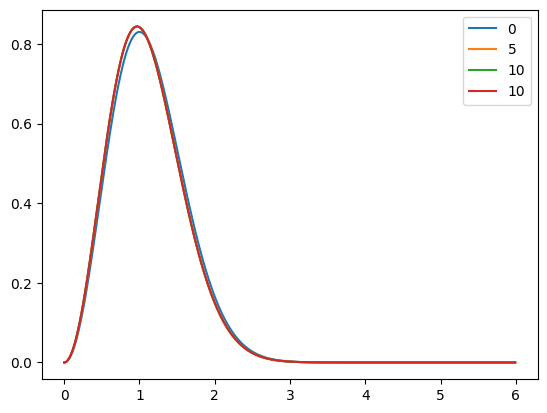

In [104]:
def iterative_GP(first_guess,alpha,nu,N,a,N_iterations,delta_E_stop):
    old_coord=first_guess
    old_old_coord=np.zeros(len(first_guess))
    old_E = np.inf
    for i in range(N_iterations):
        new_mu, new_coord=ground_state(old_coord,old_old_coord,alpha,nu,N,a)
        if i%5==0:
            plot_state(new_coord,i)
        #print("Mu at ",(i)," iteration= ",(new_mu))
        E, E_difference =true_energy(new_coord,old_coord,N,a,new_mu)
        print("E at ",(i)," iteration= ",(E))
        print("Delta_E at ",(i)," iteration= ",(E_difference))
        #print("Normalization=",(np.sum(new_coord**2)))
        if abs(E-old_E)<delta_E_stop:
            print("Convergence reached because E doesn't decrease anymore!")
            plot_state(new_coord,i)
            break
        if abs(E_difference)<delta_E_stop and i>1:
            print("Convergence reached with delta_E criterion!")
            plot_state(new_coord,i)
            break
        old_E=E
        old_old_coord=old_coord
        old_coord=new_coord
    return new_mu, E, new_coord

first_guess=np.zeros(50)
#first_guess[0]=1
mixing=0.001
iterative_GP(first_guess,mixing,0.5,1e3,1e-4,101,1e-6)


NaN in hermite_matrix? False
Inf in hermite_matrix? False
NaN in norm_factors? False
E at  0  iteration=  1.5
Delta_E at  0  iteration=  0.0
E at  1  iteration=  1.5398544760892614
Delta_E at  1  iteration=  -0.07891186548226327
E at  2  iteration=  1.5412691407861083
Delta_E at  2  iteration=  -0.0028107207905083975
E at  3  iteration=  1.538561492593825
Delta_E at  3  iteration=  0.002548733132803266
E at  4  iteration=  1.53837835327423
Delta_E at  4  iteration=  0.00014138684841456806
E at  5  iteration=  1.5385512594000808
Delta_E at  5  iteration=  -0.00019888641954317332
E at  6  iteration=  1.5385630888867656
Delta_E at  6  iteration=  -3.937085704568133e-05
Convergence reached because E doesn't decrease anymore!
E at  0  iteration=  1.5
Delta_E at  0  iteration=  0.0
E at  1  iteration=  1.5398544760894077
Delta_E at  1  iteration=  -0.07891186548255548
E at  2  iteration=  1.541269122964831
Delta_E at  2  iteration=  -0.002810685282802955
E at  3  iteration=  1.53856016292536

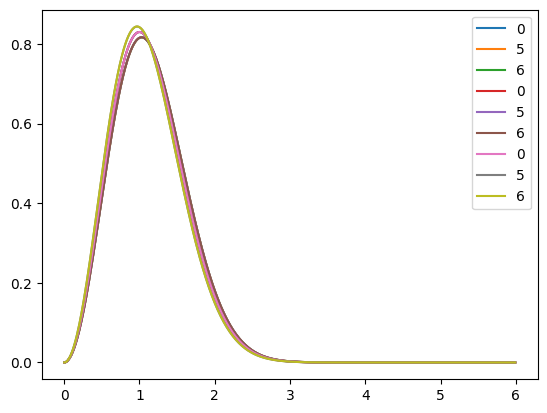

In [90]:
 #E, E_difference =true_energy(np.ones(40),np.zeros(40),1000,1e-3,1.5)
#ground_state(np.ones(15),np.zeros(15),0.5,0.5,1000,1e-3)
import cProfile
#cProfile.run('iterative_GP(first_guess, mixing, 0.5, 1e3, 1e-2, 21, 1e-3)')
# 1. Controlla overflow
coeffs = np.zeros(40); coeffs[0] = 1.0
nf = precompute_norm_factors(40)
hm = precompute_hermite_matrix(40, np.linspace(0.01, 5, 100))
print("NaN in hermite_matrix?", np.any(np.isnan(hm)))
print("Inf in hermite_matrix?", np.any(np.isinf(hm)))
print("NaN in norm_factors?",   np.any(np.isnan(nf @ hm)))

# 2. Controlla convergenza della base
result_10 = iterative_GP(np.zeros(10),mixing,0.5,1e3,1e-4,101,1e-4)
result_20 = iterative_GP(np.zeros(20),mixing,0.5,1e3,1e-4,101,1e-4)
result_40 = iterative_GP(np.zeros(40),mixing,0.5,1e3,1e-4,101,1e-4)
print(result_10[1], result_20[1], result_40[1])  # energie devono convergere
